In [1]:
import anndata as ad
import pandas as pd
import scipy.io as sio
from scipy.sparse import csr_matrix
import os

os.chdir("/Users/david/Desktop/Data_ana/Siyuan/PAIR-perturb-seq_2025-10")

# Load matrix
X = sio.mmread("./data/infercnv/expr_normalized.mtx").tocsr()

# Load metadata
meta = pd.read_csv("./data/infercnv/metadata.csv", index_col=0)

# Load gene names and cell names
genes = pd.read_csv("./data/infercnv/genes.csv")["gene"].values
cells = pd.read_csv("./data/infercnv/cells.csv")["cell"].values
# Create AnnData
adata = ad.AnnData(
    X = X.T,             # convert to cells × genes
    obs = meta,
    var = pd.DataFrame(index = genes)
)

adata.obs_names = cells
adata.var_names = genes

In [6]:
gene_order = pd.read_csv("./data/infercnv/gene_order_GRCh38_2020_V2.txt", header=None, sep=" ")

In [8]:
gene_order.columns = ["gene", "chromosome", "start", "end"]
gene_order.head()

,gene,chromosome,start,end
0,MIR1302-2HG,chr1,29554,31109
1,FAM138A,chr1,34554,36081
2,OR4F5,chr1,65419,71585
3,AL627309.1,chr1,89295,133723
4,AL627309.3,chr1,89551,91105


In [9]:
# keep only genes that exist in gene_order
common_genes = gene_order["gene"].isin(adata.var_names)

gene_order = gene_order[common_genes]
adata = adata[:, gene_order["gene"].values]

In [11]:
adata.var["chromosome"] = gene_order["chromosome"].values
adata.var["start"] = gene_order["start"].values
adata.var["end"] = gene_order["end"].values

/var/folders/fd/29msl90x01jdwg5fdg2hb47m0000gn/T/ipykernel_41964/1546136454.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["chromosome"] = gene_order["chromosome"].values


In [13]:
adata

AnnData object with n_obs × n_vars = 1697 × 23173
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode_original', 'treatment', 'assigned_tag', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.4', 'seurat_clusters'
    var: 'chromosome', 'start', 'end'

In [15]:
adata.obs["assigned_tag"].unique()

array(['NBN_CRISPRa_PQ_CasRx', 'NBN_CRISPRa_NT_CasRx',
       'NBN_CRISPRa_KU70_CasRx', 'NBN_CRISPRa_53BP1_CasRx',
       'MRE11_CRISPRa_NT_CasRx', 'NT_CRISPRa_NT_CasRx',
       'NT_CRISPRa_PQ_CasRx', 'NT_CRISPRa_KU70_CasRx',
       'NT_CRISPRa_53BP1_CasRx', 'NT_CRISPRa_DNPKcs_CasRx',
       'NBN_CRISPRa_DNPKcs_CasRx'], dtype=object)

In [35]:
import infercnvpy as cnv

cnv.tl.infercnv(
    adata,
    reference_key="assigned_tag",
    reference_cat=[
        "NT_CRISPRa_NT_CasRx",
        # "NBN_CRISPRa_NT_CasRx",
        # "NT_CRISPRa_PQ_CasRx",
        # "NT_CRISPRa_KU70_CasRx",
        # "NT_CRISPRa_53BP1_CasRx",
        # "NT_CRISPRa_DNPKcs_CasRx",
        # "NBN_CRISPRa_PQ_CasRx",
        # "NBN_CRISPRa_KU70_CasRx",
        # "NBN_CRISPRa_53BP1_CasRx",
        # "NBN_CRISPRa_DNPKcs_CasRx",
        # "MRE11_CRISPRa_NT_CasRx",
    ],
    window_size = 500,
    exclude_chromosomes=None,
    lfc_clip=2,
    step=5
)

100%|██████████| 1/1 [00:03<00:00,  3.91s/it]


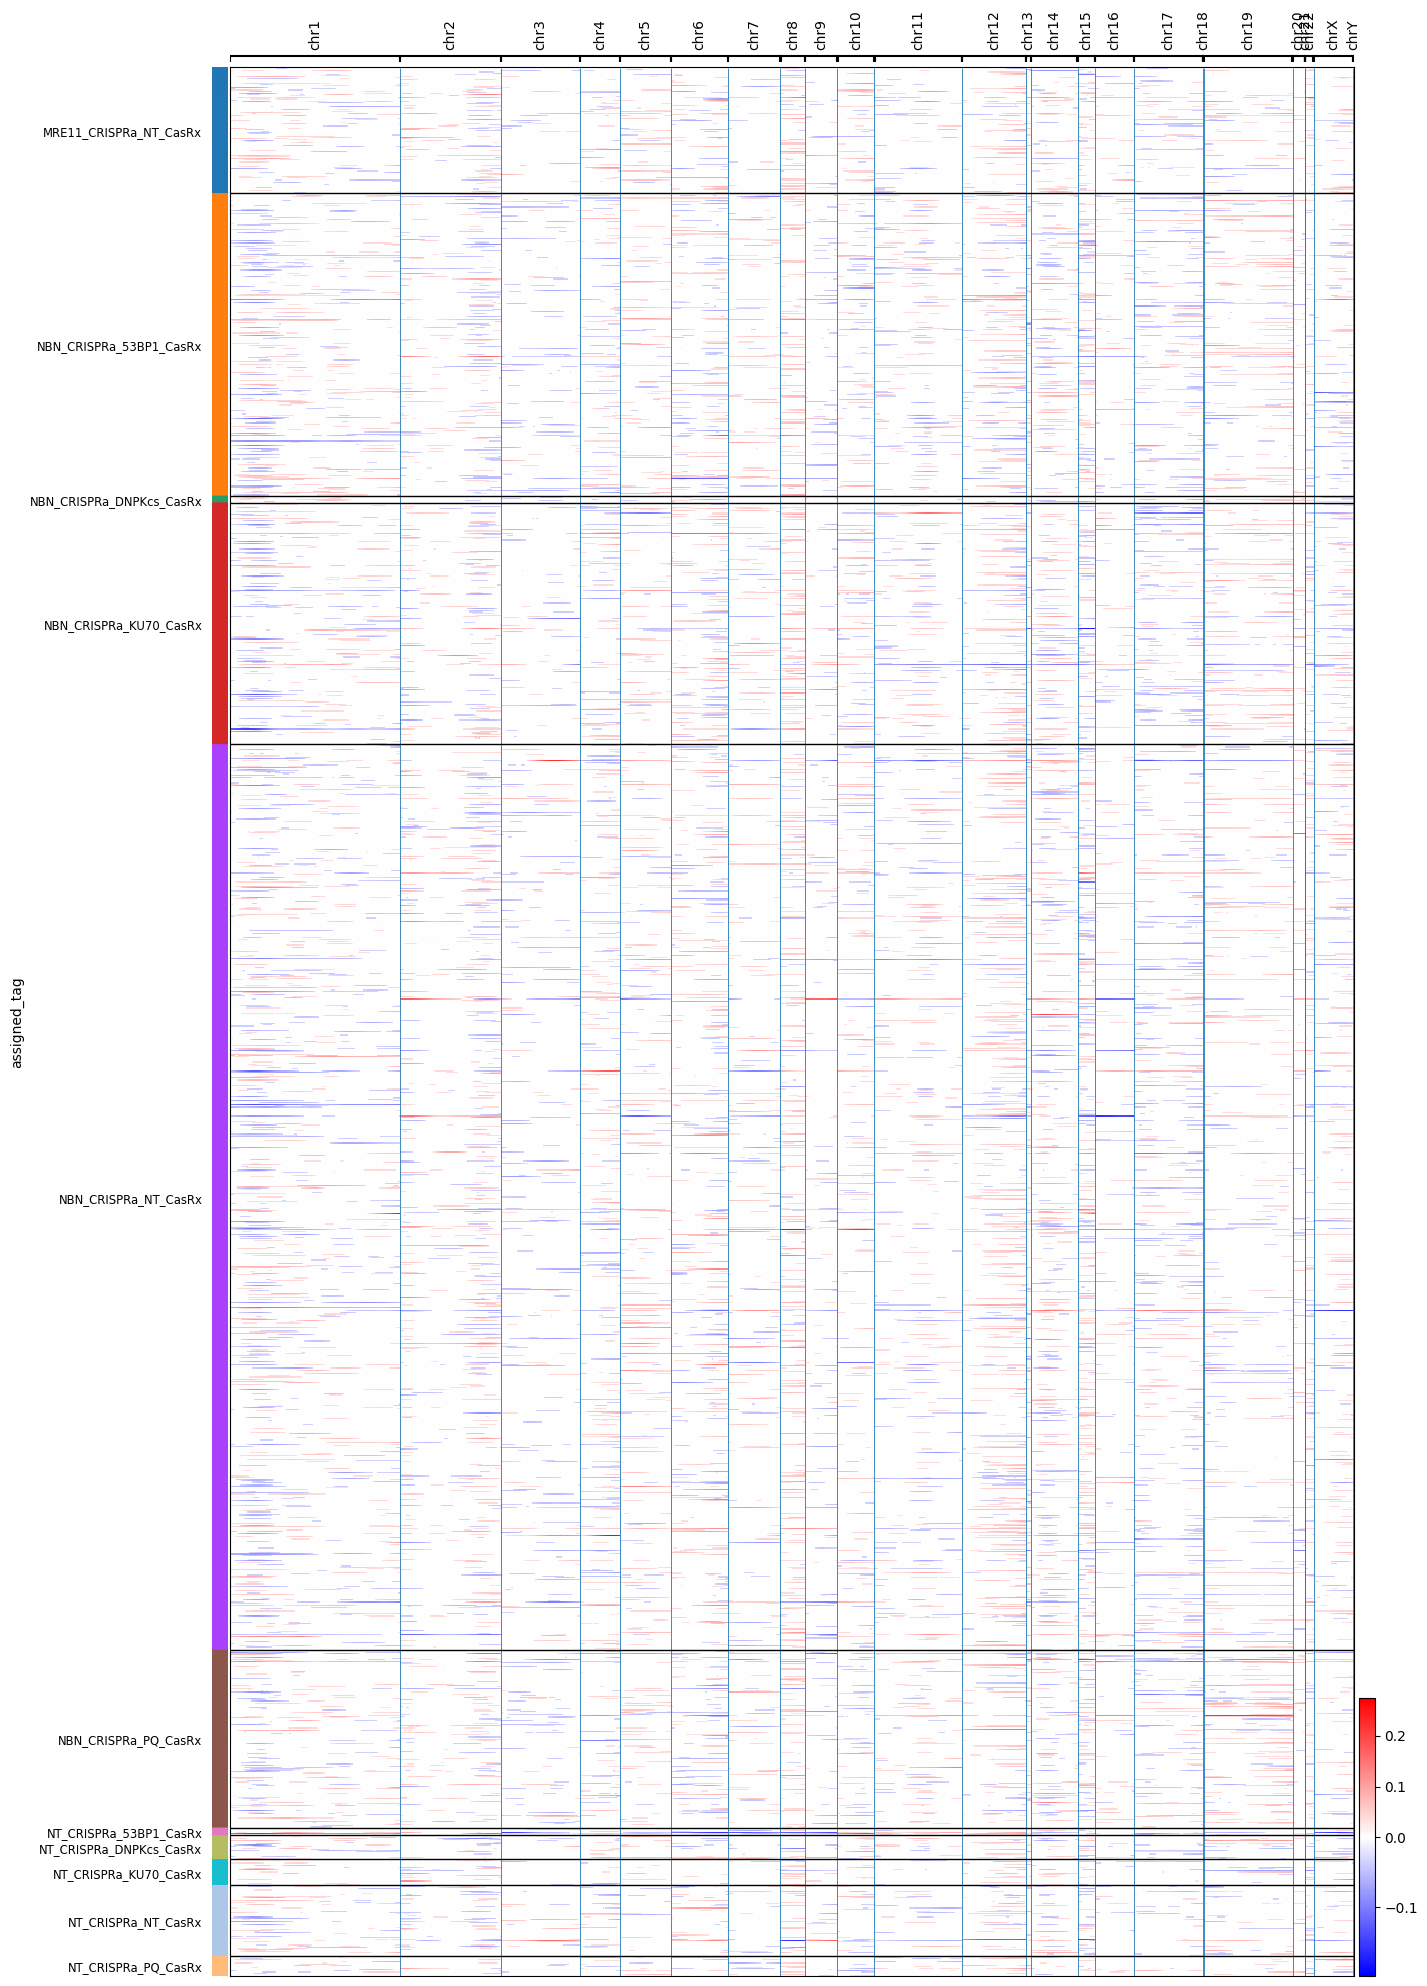

In [36]:
cnv.pl.chromosome_heatmap(adata, groupby="assigned_tag", figsize=(15, 25))

In [38]:
adata

AnnData object with n_obs × n_vars = 1697 × 23173
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode_original', 'treatment', 'assigned_tag', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.4', 'seurat_clusters'
    var: 'chromosome', 'start', 'end'
    uns: 'cnv', 'assigned_tag_colors'
    obsm: 'X_cnv'

In [50]:
adata.obs["cnv_leiden"] = adata.obs["seurat_clusters"].astype(str)

In [45]:
import scanpy as sc
sc.pp.neighbors(adata)

In [44]:
adata

AnnData object with n_obs × n_vars = 1697 × 23173
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'barcode_original', 'treatment', 'assigned_tag', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.4', 'seurat_clusters', 'cnv_leiden', 'cnv_score'
    var: 'chromosome', 'start', 'end'
    uns: 'cnv', 'assigned_tag_colors', 'pca', 'neighbors'
    obsm: 'X_cnv', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [47]:
adata.uns["cnv_neighbors"] = adata.uns["neighbors"]
cnv.tl.umap(adata)

In [48]:
cnv.tl.cnv_score(adata)

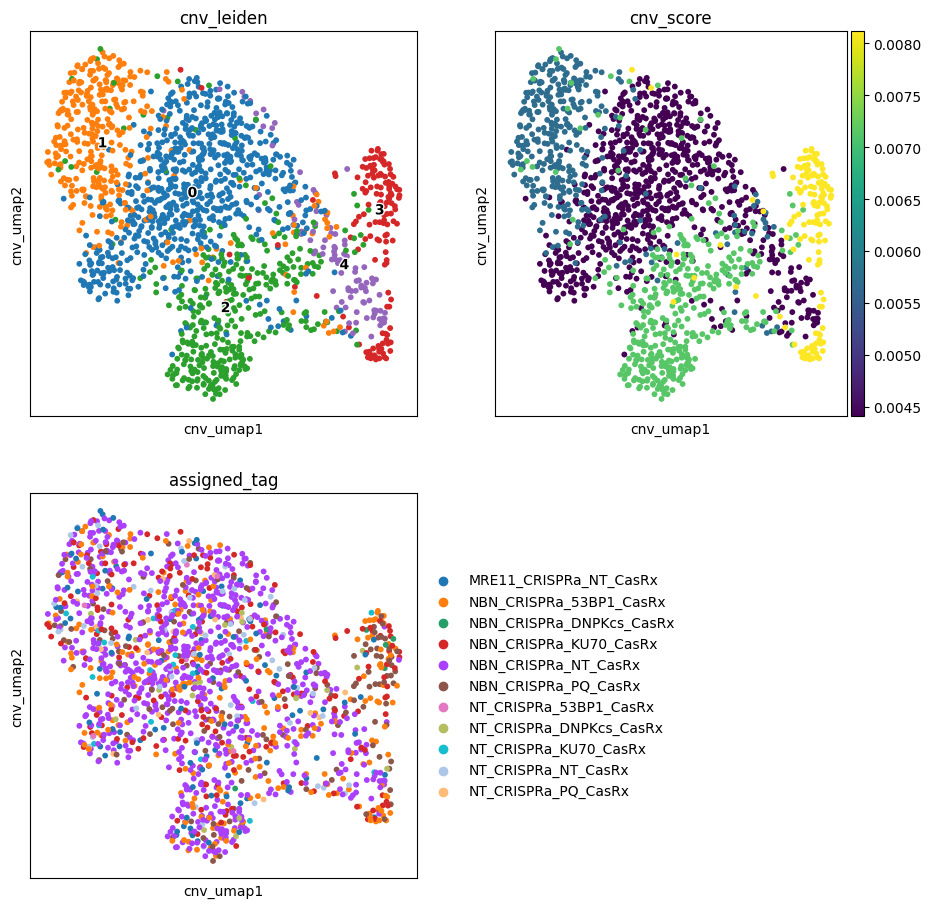

In [51]:
import matplotlib.pyplot as plt
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="assigned_tag", ax=ax3)